# Predictive Modelling Using Machine Learning
## Credit Card Default Classification — Complete Python Project — All 5 Assessment Tasks

**Programme:** MSc in Artificial Intelligence  
**Module:** Introduction to Artificial Intelligence (AI7001)  
**Student:** Sattar Rafiezadeh Naghani

This notebook presents the complete practical workflow in a **manual-style format**:

**Python step → executable code → output/figure → short interpretation**

All analysis is based on the supplied `Credit_Card.csv` dataset. The notebook is designed so that each result can be traced directly to the Python code that generated it.

## Reproducibility note

Place `Credit_Card.csv` in the **same folder** as this notebook before running it.  
The notebook uses a relative path (`Credit_Card.csv`) so it can run after cloning or downloading the GitHub repository.


## 1. Project objective

The task is to predict `default.payment.next.month`, where:

- `0` = No default
- `1` = Default

Because default is the minority class, accuracy alone is not sufficient. The project therefore compares **accuracy, precision, recall, F1-score and ROC-AUC**, and also inspects confusion matrices and model interpretation outputs.

## 2. Import libraries and load the dataset

The first step loads the dataset and the Python libraries used for data preparation, modelling, evaluation and visualisation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

import shap

DATA_PATH = "Credit_Card.csv"

df_raw = pd.read_csv(DATA_PATH, sep=";", low_memory=False)

print("Dataset shape:", df_raw.shape)
display(df_raw.head())

Dataset shape: (34788, 30)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


### Interpretation

The supplied file contains **34,788 rows and 30 columns**. The target column is `default.payment.next.month`.

## 3. Duplicate audit and target distribution

Duplicate records must be removed before the train/test split. Otherwise, the same customer pattern could appear in both sets and make model performance look better than it really is.

In [2]:
print("Exact duplicate rows:", df_raw.duplicated().sum())
print("Duplicate IDs:", df_raw.duplicated(subset=["ID"]).sum())

df = df_raw.drop_duplicates().copy()

print("Shape after duplicate removal:", df.shape)
print("\nTarget counts:")
print(df["default.payment.next.month"].value_counts().sort_index())
print("\nTarget percentages:")
print((df["default.payment.next.month"].value_counts(normalize=True).sort_index() * 100).round(2))

Exact duplicate rows: 4788
Duplicate IDs: 4788
Shape after duplicate removal: (30000, 30)

Target counts:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Target percentages:
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


### Interpretation

Python identifies **4,788 exact duplicate rows**. After removal, **30,000 unique records** remain.

The cleaned dataset contains:

- **23,364 non-default cases**
- **6,636 default cases**
- Default rate ≈ **22.12%**

This confirms a meaningful class imbalance.

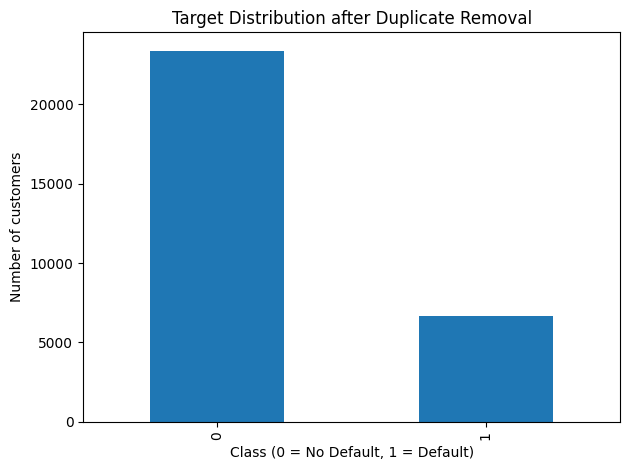

In [3]:
df["default.payment.next.month"].value_counts().sort_index().plot(
    kind="bar",
    title="Target Distribution after Duplicate Removal"
)
plt.xlabel("Class (0 = No Default, 1 = Default)")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

## 4. Missing-value audit

Missing values are checked before modelling so that the imputation strategy can be defined explicitly.

In [4]:
missing = df.isna().sum()
missing_table = missing[missing > 0].sort_values(ascending=False).to_frame("Missing values")
missing_table["Percentage"] = (missing_table["Missing values"] / len(df) * 100).round(2)
display(missing_table)

,Missing values,Percentage
LIMIT_BAL,1500,5.0
SEX,1500,5.0
EDUCATION,1500,5.0
MARRIAGE,1500,5.0
AGE,1500,5.0
PAY_AMT1,1500,5.0
PAY_AMT2,1500,5.0
LIMIT_BAL_LOG,1500,5.0


### Interpretation

Eight fields contain missing values. Numerical fields will be **median-imputed**, while categorical fields will use the **most frequent category**. Median imputation is appropriate here because several financial variables are strongly skewed.

## 5. Inspect malformed engineered variables and target leakage

Two engineered fields require special attention:

- `LIMIT_BAL_LOG` contains malformed string formatting, so it is reconstructed from `LIMIT_BAL`.
- `risk_leak` is checked as a potential leakage variable because it appears to contain information extremely close to the target.

In [5]:
def clean_weird_decimal(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if s.count(".") <= 1:
        try:
            return float(s)
        except ValueError:
            return np.nan

    sign = -1 if s.startswith("-") else 1
    digits = re.sub(r"\D", "", s)
    if not digits:
        return np.nan

    return sign * (int(digits) / (10 ** (len(digits) - 1)))

df["risk_leak_clean"] = df["risk_leak"].apply(clean_weird_decimal)

risk_corr = df[["risk_leak_clean", "default.payment.next.month"]].corr().iloc[0, 1]
print("Correlation between cleaned risk_leak and target:", round(risk_corr, 4))

print("\nCross-tab using a simple 0.5 threshold:")
display(pd.crosstab(
    df["default.payment.next.month"],
    (df["risk_leak_clean"] > 0.5).rename("risk_leak > 0.5")
))

Correlation between cleaned risk_leak and target: 0.9719

Cross-tab using a simple 0.5 threshold:


risk_leak > 0.5,False,True
default.payment.next.month,,
0,23364,0
1,0,6636


### Interpretation

The cleaned `risk_leak` variable has an extremely high relationship with the target and effectively separates defaults from non-defaults. This is **target leakage**, not legitimate predictive information.

Therefore, `risk_leak` is used only as a diagnostic and is **excluded from model training and SHAP interpretation**.

## 6. Descriptive statistics

Key numerical variables are summarised before modelling.

In [6]:
df["LIMIT_BAL_LOG_clean"] = np.log(df["LIMIT_BAL"])

key_stats = df[
    ["LIMIT_BAL", "AGE", "BILL_AMT_SUM", "LIMIT_BAL_LOG_clean", "risk_leak_clean"]
].agg(["mean", "median", "std"]).T

key_stats.columns = ["Mean", "Median", "Std. deviation"]
display(key_stats.round(3))

,Mean,Median,Std. deviation
LIMIT_BAL,183123.848,140000.000,232390.943
AGE,35.498,34.000,9.222
BILL_AMT_SUM,294750.685,128032.500,569241.472
LIMIT_BAL_LOG_clean,11.688,11.849,0.970
risk_leak_clean,0.221,0.037,0.427


### Data-quality consistency checks

Two additional checks were performed before modelling:

1. `BILL_AMT_SUM` was compared with the row-wise sum of `BILL_AMT1` to `BILL_AMT6`.
2. `RISK_RATING` was compared with `PAY_0` to identify whether it contains independent information or a deterministic grouping of the payment-status variable.

In [7]:
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
calculated_bill_sum = df[bill_cols].sum(axis=1)
bill_sum_mismatch = (df["BILL_AMT_SUM"] - calculated_bill_sum).abs() > 1e-9
print("Rows where BILL_AMT_SUM differs from BILL_AMT1..6 sum:", int(bill_sum_mismatch.sum()))

risk_pay0_map = (
    df[["PAY_0", "RISK_RATING"]]
    .dropna()
    .drop_duplicates()
    .sort_values(["PAY_0", "RISK_RATING"])
)
print("\nObserved PAY_0 -> RISK_RATING combinations:")
display(risk_pay0_map)


Rows where BILL_AMT_SUM differs from BILL_AMT1..6 sum: 291

Observed PAY_0 -> RISK_RATING combinations:


,PAY_0,RISK_RATING
9,-2,1
1,-1,1
2,0,1
13,1,2
0,2,2
129,3,3
360,4,3
3537,5,3
4801,6,3
2324,7,3


**Interpretation:** 291 rows contain a mismatch between `BILL_AMT_SUM` and the six component bill fields, so the engineered sum is treated as a data-quality limitation rather than assumed to be correct in every row. `RISK_RATING` is a deterministic grouping of `PAY_0`, so the importance of these two variables should not be interpreted as two independent pieces of evidence.

## 7. Exploratory Data Analysis (EDA)

The following plots examine skewness, outliers, categorical risk structure and correlation with the target.

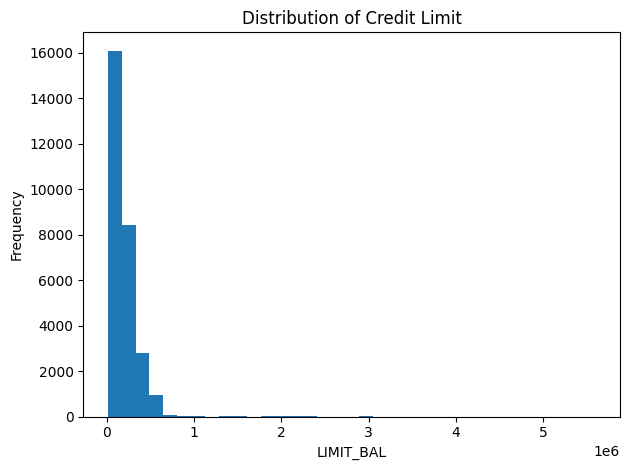

In [8]:
df["LIMIT_BAL"].dropna().plot(
    kind="hist",
    bins=35,
    title="Distribution of Credit Limit"
)
plt.xlabel("LIMIT_BAL")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Interpretation:** `LIMIT_BAL` is right-skewed. This supports robust imputation and scaling rather than assuming a normal distribution.

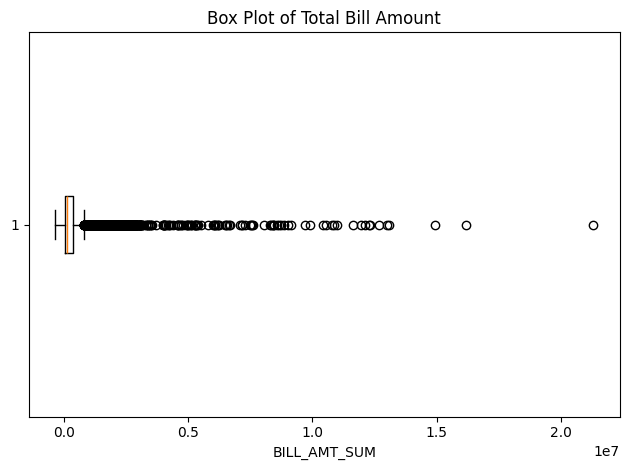

In [9]:
plt.boxplot(df["BILL_AMT_SUM"].dropna(), vert=False)
plt.title("Box Plot of Total Bill Amount")
plt.xlabel("BILL_AMT_SUM")
plt.tight_layout()
plt.show()

**Interpretation:** `BILL_AMT_SUM` contains many extreme values. They are not removed automatically because some may be real customer values. A separate consistency check is therefore used to compare `BILL_AMT_SUM` with the sum of `BILL_AMT1` to `BILL_AMT6`.

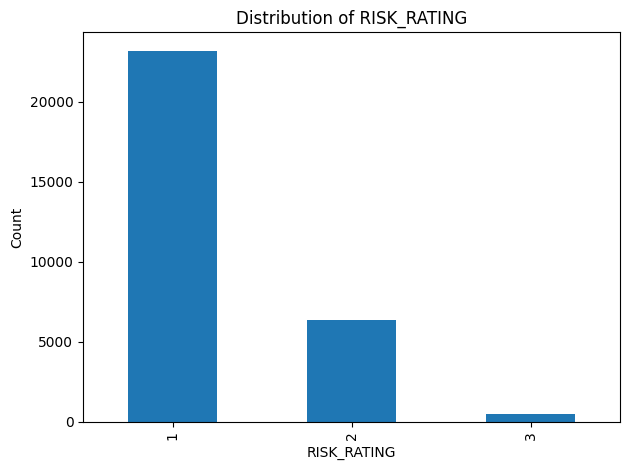

In [10]:
df["RISK_RATING"].value_counts().sort_index().plot(
    kind="bar",
    title="Distribution of RISK_RATING"
)
plt.xlabel("RISK_RATING")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Interpretation:** `RISK_RATING` is strongly concentrated in the lower category, with relatively few high-risk observations.

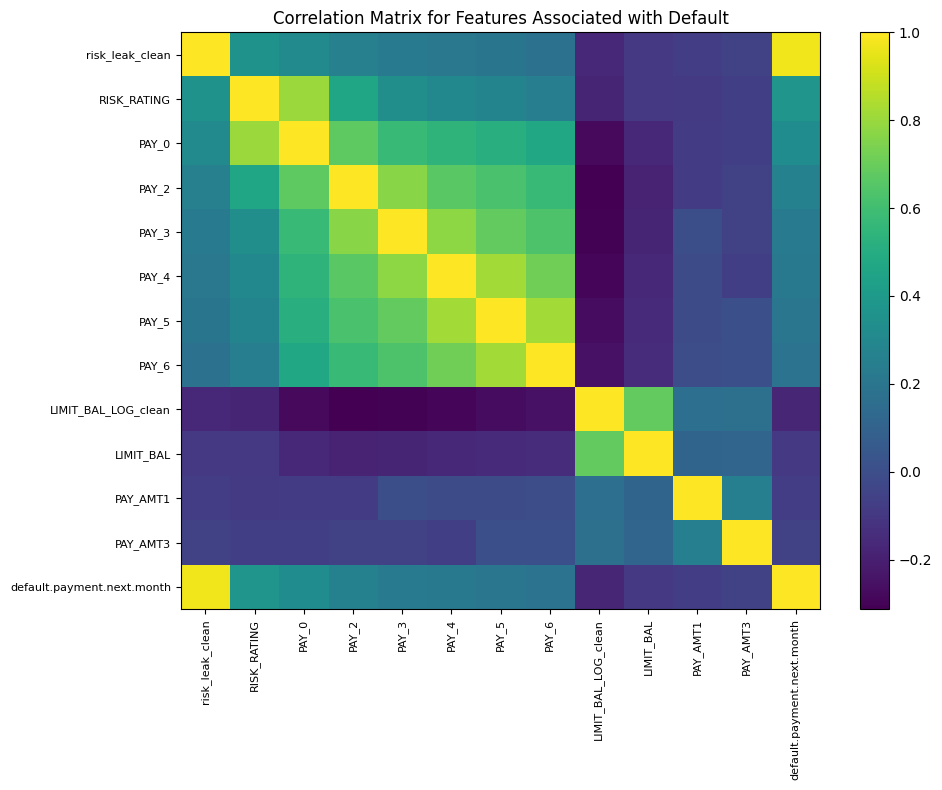

In [11]:
corr_features = [
    "risk_leak_clean", "RISK_RATING",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "LIMIT_BAL_LOG_clean", "LIMIT_BAL",
    "PAY_AMT1", "PAY_AMT3",
    "default.payment.next.month"
]

corr = df[corr_features].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=8)
ax.set_title("Correlation Matrix for Features Associated with Default")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Categorical distributions required by Task 1

The assessment brief specifically asks for inspection of **SEX, EDUCATION, MARRIAGE, CITY and RISK_RATING**.  
The following Python-generated charts show the frequency distribution of each categorical feature.


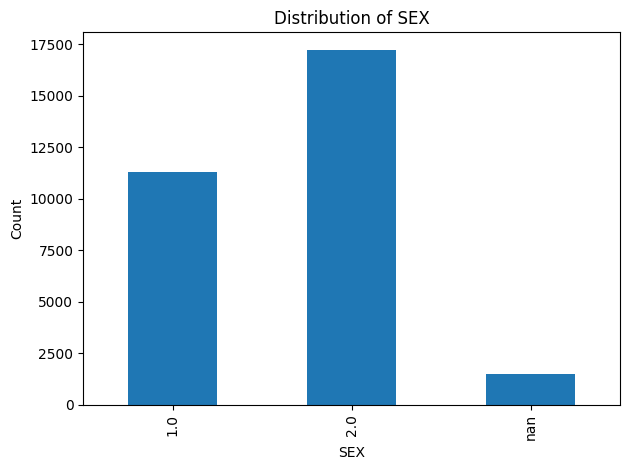

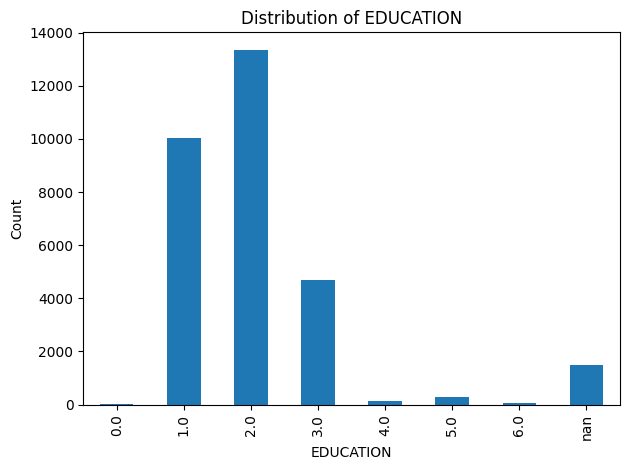

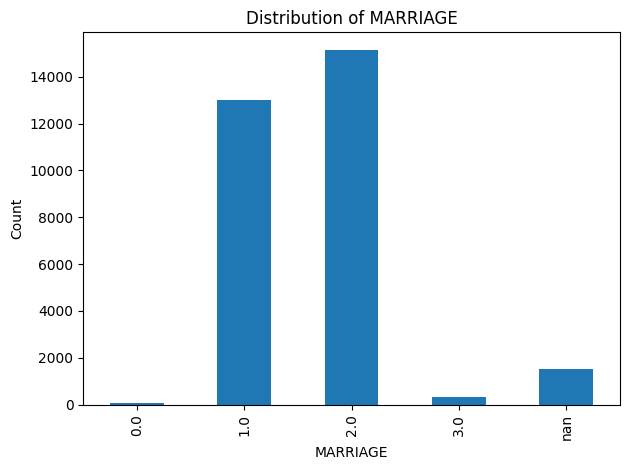

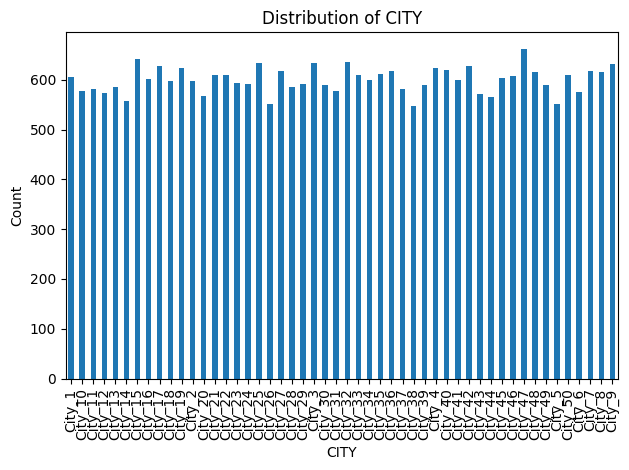

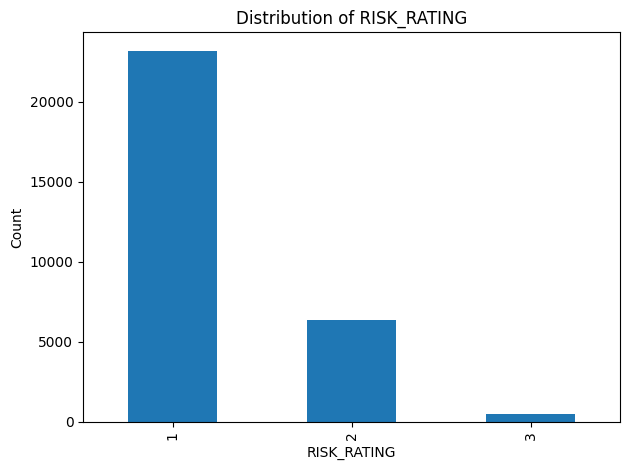

In [12]:
categorical_eda = ["SEX", "EDUCATION", "MARRIAGE", "CITY", "RISK_RATING"]

for col in categorical_eda:
    counts = df[col].value_counts(dropna=False).sort_index()
    counts.plot(kind="bar", title=f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


**Interpretation:** These distributions make class concentration, rare categories and possible data-quality issues visible before encoding. `RISK_RATING` is especially imbalanced, while the remaining categorical variables provide demographic and location context that may also require fairness monitoring.


### EDA summary

The exploratory analysis shows:

- Financial variables are often skewed and contain legitimate extreme observations.
- Payment-history variables (`PAY_0` to `PAY_6`) are strongly associated with default risk.
- `RISK_RATING` is informative but should be governed carefully.
- `risk_leak` is clearly unsuitable for legitimate prediction because it leaks target information.

## 8. Preprocessing and train/test split

The modelling pipeline performs the following operations:

1. Remove `ID`, `risk_leak` and the malformed original `LIMIT_BAL_LOG`.
2. Reconstruct a clean logarithmic credit-limit feature.
3. Median-impute numerical data and keep missingness indicators.
4. Standardise numerical features.
5. Mode-impute and one-hot encode categorical features.
6. Use an **80:20 stratified train/test split** with `random_state=42`.

In [13]:
target = "default.payment.next.month"

X = df.drop(
    columns=[target, "risk_leak", "risk_leak_clean", "LIMIT_BAL_LOG", "ID"]
).copy()

X["LIMIT_BAL_LOG_clean"] = np.log(X["LIMIT_BAL"])
y = df[target].copy()

categorical_cols = ["SEX", "EDUCATION", "MARRIAGE", "CITY", "RISK_RATING"]
numerical_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler())
        ]),
        numerical_cols
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_cols
    )
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
transformed_feature_names = preprocessor.get_feature_names_out()
print("Transformed training matrix:", X_train_transformed.shape)
print("Transformed test matrix:", X_test_transformed.shape)

Training set: (24000, 27)
Test set: (6000, 27)


Transformed training matrix: (24000, 93)
Transformed test matrix: (6000, 93)


### Before-and-after preprocessing example

Task 2 asks for before-and-after evidence where possible.  
The first table below shows raw input values. The second shows the corresponding transformed model matrix after **imputation, scaling and one-hot encoding**.


In [14]:
raw_example_cols = ["LIMIT_BAL", "AGE", "SEX", "CITY", "RISK_RATING"]
print("BEFORE preprocessing:")
display(X_train[raw_example_cols].head(5))

sample_transformed = preprocessor.transform(X_train.head(5))
sample_dense = sample_transformed.toarray() if hasattr(sample_transformed, "toarray") else sample_transformed
sample_df = pd.DataFrame(sample_dense, columns=transformed_feature_names)

# Show a compact set of transformed fields so the before/after comparison remains readable.
selected_after_cols = []
for token in ["LIMIT_BAL", "AGE", "SEX", "CITY", "RISK_RATING"]:
    matches = [c for c in sample_df.columns if token in c]
    selected_after_cols.extend(matches[:3])

selected_after_cols = list(dict.fromkeys(selected_after_cols))[:12]

print("\nAFTER preprocessing (selected transformed features):")
display(sample_df[selected_after_cols].head(5).round(3))

print("\nMissing values in transformed sample:", int(np.isnan(sample_dense).sum()))


BEFORE preprocessing:


,LIMIT_BAL,AGE,SEX,CITY,RISK_RATING
22788,160000.0,33.0,2.0,City_8,2
29006,150000.0,34.0,2.0,City_45,2
16950,10000.0,50.0,1.0,City_14,2
22280,220000.0,29.0,2.0,City_28,1
11346,310000.0,32.0,2.0,City_12,2



AFTER preprocessing (selected transformed features):


,num__LIMIT_BAL,num__LIMIT_BAL_LOG_clean,num__missingindicator_LIMIT_BAL,num__AGE,num__missingindicator_AGE,cat__MARRIAGE_0.0,cat__SEX_1.0,cat__SEX_2.0,cat__CITY_City_1,cat__CITY_City_10,cat__CITY_City_11,cat__RISK_RATING_1
0,-0.093,0.303,-0.232,-0.265,-0.226,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.138,0.234,-0.232,-0.154,-0.226,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.759,-2.633,-0.232,1.630,-0.226,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.173,0.640,-0.232,-0.711,-0.226,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.573,1.003,-0.232,-0.376,-0.226,0.0,0.0,1.0,0.0,0.0,0.0,0.0



Missing values in transformed sample: 0


**Interpretation:** Numerical values are converted to the scaled model space, categorical values are converted to indicator columns, and missing inputs are resolved by the preprocessing pipeline. The transformed sample contains no remaining `NaN` values.


### Interpretation

The model is trained on **24,000 records** and tested on **6,000 records**. Stratification preserves the default/non-default ratio in both sets.

After preprocessing and one-hot encoding, the model matrix contains the expanded transformed feature set used by all classifiers.

## 9. Baseline model selection

Five algorithms are compared because they represent different modelling assumptions:

- **Logistic Regression** — transparent linear baseline
- **Linear SVM** — large-margin linear classifier
- **Decision Tree** — interpretable nonlinear model
- **Random Forest** — ensemble model that reduces single-tree variance
- **K-Nearest Neighbours** — local similarity-based baseline

This gives a broader comparison than testing several closely related classifiers.

### Initial hyperparameters before tuning

Task 3 requires the baseline settings to be recorded **before** optimisation.  
The table below documents the key initial hyperparameters used for all five classifiers.


In [15]:
initial_hyperparameters = pd.DataFrame([
    ["Logistic Regression", "C=1; solver='lbfgs'; max_iter=1000", "Transparent linear baseline"],
    ["Linear SVM", "C=1; loss='squared_hinge'; max_iter=1000", "Large-margin classifier"],
    ["Decision Tree", "criterion='gini'; max_depth=None; min_samples_leaf=1", "Interpretable nonlinear baseline"],
    ["Random Forest", "n_estimators=100; max_depth=None; max_features='sqrt'", "Ensemble nonlinear model"],
    ["KNN", "n_neighbors=5; weights='uniform'; metric='minkowski'; p=2", "Local-similarity baseline"]
], columns=["Model", "Key initial hyperparameters", "Purpose"])

display(initial_hyperparameters)


,Model,Key initial hyperparameters,Purpose
0,Logistic Regression,C=1; solver='lbfgs'; max_iter=1000,Transparent linear baseline
1,Linear SVM,C=1; loss='squared_hinge'; max_iter=1000,Large-margin classifier
2,Decision Tree,criterion='gini'; max_depth=None; min_samples_...,Interpretable nonlinear baseline
3,Random Forest,n_estimators=100; max_depth=None; max_features...,Ensemble nonlinear model
4,KNN,n_neighbors=5; weights='uniform'; metric='mink...,Local-similarity baseline


In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=1
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Model selection uses only the training data. Each CV fold fits its own preprocessing pipeline.
cv_rows = []
for name, model in models.items():
    cv_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    cv_scores = cross_validate(
        cv_pipe,
        X_train,
        y_train,
        cv=3,
        scoring={"f1": "f1", "roc_auc": "roc_auc"},
        n_jobs=1
    )
    cv_rows.append({
        "Model": name,
        "CV F1": cv_scores["test_f1"].mean(),
        "CV AUC-ROC": cv_scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV F1", ascending=False)
print("Training-only 3-fold CV used for model selection:")
display(cv_results.round(4))
selected_model_name = cv_results.iloc[0]["Model"]
print("Selected model for tuning:", selected_model_name)

# Fit all baseline pipelines on the complete training set and report final test-set metrics.
rows = []
fitted_models = {}
for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    pred = pipe.predict(X_test)
    if hasattr(pipe, "predict_proba"):
        score = pipe.predict_proba(X_test)[:, 1]
    else:
        score = pipe.decision_function(X_test)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "AUC-ROC": roc_auc_score(y_test, score)
    })

results = pd.DataFrame(rows).sort_values("AUC-ROC", ascending=False)
print("Final baseline test-set evaluation:")
display(results.round(4))

Training-only 3-fold CV used for model selection:


,Model,CV F1,CV AUC-ROC
3,Random Forest,0.4715,0.7651
4,KNN,0.4297,0.7011
0,Logistic Regression,0.4269,0.7449
1,Linear SVM,0.4209,0.7452
2,Decision Tree,0.4016,0.6152


Selected model for tuning: Random Forest


Final baseline test-set evaluation:


,Model,Accuracy,Precision,Recall,F1,AUC-ROC
3,Random Forest,0.8157,0.6483,0.3640,0.4662,0.7591
0,Logistic Regression,0.8002,0.5886,0.3203,0.4148,0.7274
1,Linear SVM,0.7988,0.5822,0.3203,0.4132,0.7266
4,KNN,0.7878,0.5317,0.3414,0.4158,0.6916
2,Decision Tree,0.7365,0.4023,0.3941,0.3982,0.6139


### Baseline result

The five algorithms are selected and compared using **3-fold cross-validation on the training set only**. Random Forest has the strongest training-CV F1 and AUC-ROC, so it is selected for tuning before the held-out test set is used for final reporting. The test-set table is retained as the final baseline evaluation, not as the basis for model selection.

## 10. Confusion matrices

A confusion matrix shows exactly how many non-defaults and defaults were classified correctly or incorrectly. This makes minority-class errors visible in a way that aggregate accuracy cannot.

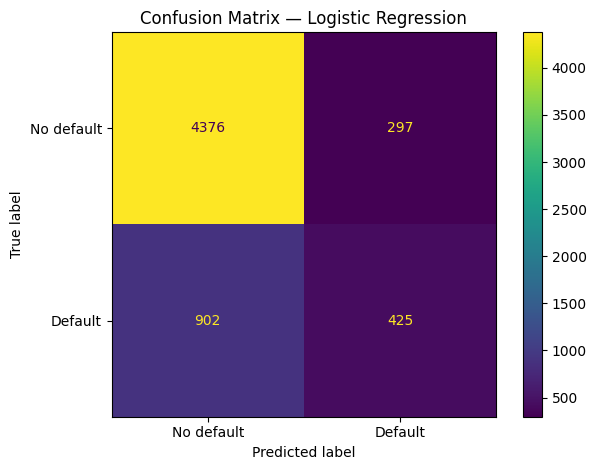

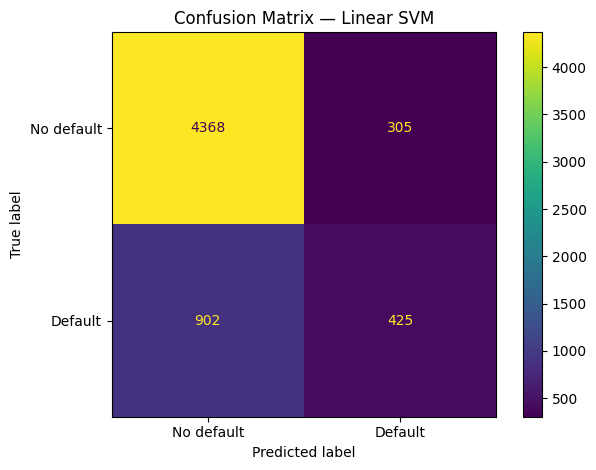

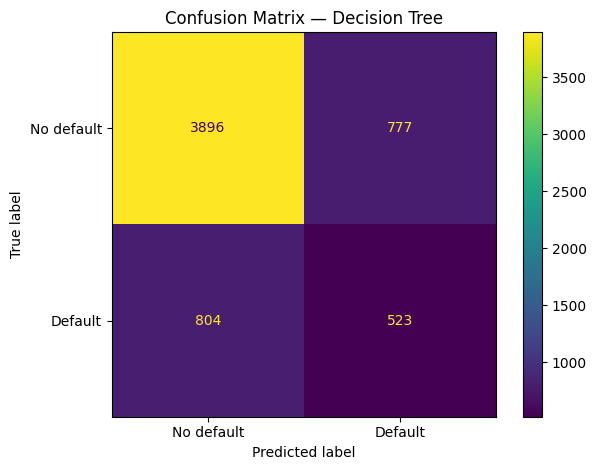

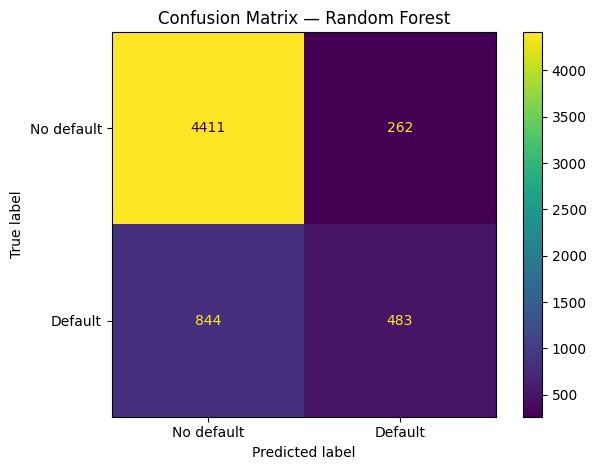

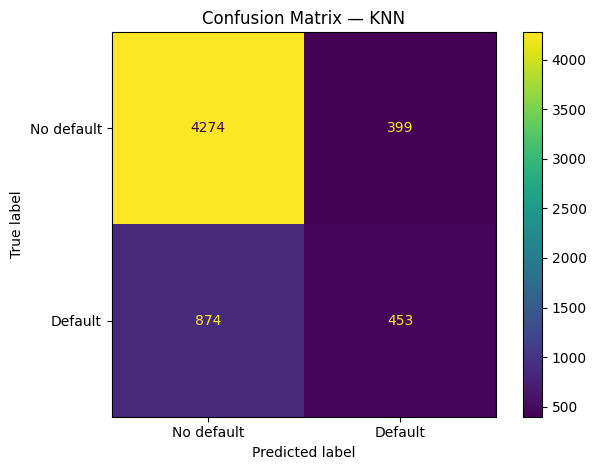

In [17]:
for name, pipe in fitted_models.items():
    pred = pipe.predict(X_test)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, pred),
        display_labels=["No default", "Default"]
    )
    disp.plot()
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

### Interpretation

All five baseline models classify the majority non-default class more successfully than the minority default class. Random Forest offers the strongest overall balance among the baseline models.

## 11. ROC curves

ROC curves compare the trade-off between true-positive rate and false-positive rate across thresholds. A higher AUC generally indicates better ranking ability.

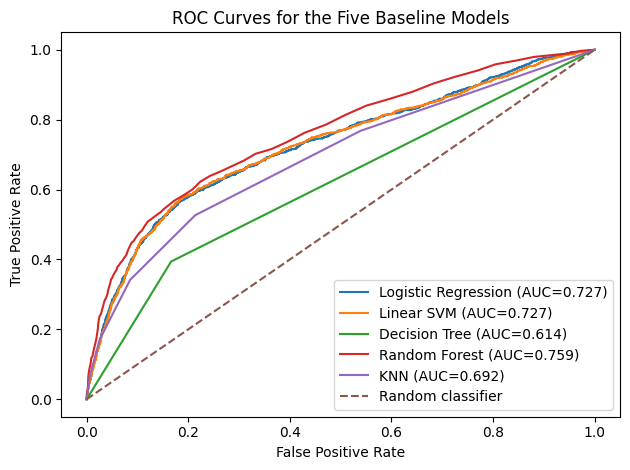

In [18]:
for name, pipe in fitted_models.items():
    if hasattr(pipe, "predict_proba"):
        score = pipe.predict_proba(X_test)[:, 1]
    else:
        score = pipe.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for the Five Baseline Models")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Hyperparameter tuning with RandomizedSearchCV

Task 4 requires the best-performing model to be tuned using **GridSearchCV or RandomizedSearchCV**.

The baseline Random Forest is therefore tuned with **RandomizedSearchCV using three-fold cross-validation and F1-score as the optimisation metric**. F1 is used because the target is imbalanced and the project needs a balance between precision and recall.

The candidate configurations below include different tree counts, depths, leaf sizes, feature-sampling strategies and class-weighting choices.


In [19]:
# RandomizedSearchCV evaluates complete pipelines so every CV fold fits its own
# imputation, scaling and one-hot encoding. This avoids validation-fold leakage.

rf_candidate_distributions = [
    {
        "model__n_estimators": [60],
        "model__max_depth": [12],
        "model__min_samples_leaf": [4],
        "model__max_features": ["sqrt"],
        "model__class_weight": ["balanced_subsample"]
    },
    {
        "model__n_estimators": [40],
        "model__max_depth": [8],
        "model__min_samples_leaf": [1],
        "model__max_features": ["sqrt"],
        "model__class_weight": [None]
    },
    {
        "model__n_estimators": [80],
        "model__max_depth": [10],
        "model__min_samples_leaf": [2],
        "model__max_features": ["sqrt"],
        "model__class_weight": ["balanced"]
    },
    {
        "model__n_estimators": [100],
        "model__max_depth": [None],
        "model__min_samples_leaf": [1],
        "model__max_features": ["sqrt"],
        "model__class_weight": [None]
    },
    {
        "model__n_estimators": [60],
        "model__max_depth": [10],
        "model__min_samples_leaf": [6],
        "model__max_features": ["log2"],
        "model__class_weight": ["balanced"]
    },
    {
        "model__n_estimators": [120],
        "model__max_depth": [8],
        "model__min_samples_leaf": [4],
        "model__max_features": ["log2"],
        "model__class_weight": ["balanced_subsample"]
    }
]

rf_search_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_search = RandomizedSearchCV(
    estimator=rf_search_pipeline,
    param_distributions=rf_candidate_distributions,
    n_iter=6,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=1,
    return_train_score=False,
    refit=True
)

rf_search.fit(X_train, y_train)

best_params_clean = {
    key.replace("model__", ""): value
    for key, value in rf_search.best_params_.items()
}
print("Best CV F1:", round(rf_search.best_score_, 4))
print("Best parameters:")
print(best_params_clean)

search_results = pd.DataFrame(rf_search.cv_results_)
display(
    search_results[
        ["params", "mean_test_score", "std_test_score", "rank_test_score"]
    ].sort_values("rank_test_score").head(6)
)

Best CV F1: 0.5439
Best parameters:
{'n_estimators': 80, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced'}


,params,mean_test_score,std_test_score,rank_test_score
2,"{'model__n_estimators': 80, 'model__min_sample...",0.543903,0.009064,1
5,"{'model__n_estimators': 120, 'model__min_sampl...",0.542972,0.010353,2
4,"{'model__n_estimators': 60, 'model__min_sample...",0.542594,0.006927,3
0,"{'model__n_estimators': 60, 'model__min_sample...",0.541888,0.008948,4
1,"{'model__n_estimators': 40, 'model__min_sample...",0.475099,0.002402,5
3,"{'model__n_estimators': 100, 'model__min_sampl...",0.471535,0.002466,6


### Fit the selected Random Forest and compare it with the baseline

The best parameter set returned by `RandomizedSearchCV` is now fitted again through the full preprocessing pipeline so that the final tuned model remains fully reproducible from the raw dataframe.


In [20]:
# RandomizedSearchCV refits the best complete pipeline on all training data.
tuned_model = rf_search.best_estimator_

tuned_pred = tuned_model.predict(X_test)
tuned_prob = tuned_model.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred),
    "Recall": recall_score(y_test, tuned_pred),
    "F1": f1_score(y_test, tuned_pred),
    "AUC-ROC": roc_auc_score(y_test, tuned_prob)
}

baseline_rf_row = results.loc[results["Model"] == "Random Forest"].iloc[0]
comparison = pd.DataFrame([
    {
        "Version": "Baseline RF",
        "Accuracy": baseline_rf_row["Accuracy"],
        "Precision": baseline_rf_row["Precision"],
        "Recall": baseline_rf_row["Recall"],
        "F1": baseline_rf_row["F1"],
        "AUC-ROC": baseline_rf_row["AUC-ROC"]
    },
    {"Version": "Tuned RF", **tuned_metrics}
])

display(comparison.round(4))

,Version,Accuracy,Precision,Recall,F1,AUC-ROC
0,Baseline RF,0.8157,0.6483,0.3640,0.4662,0.7591
1,Tuned RF,0.7885,0.5201,0.5644,0.5414,0.7707


### Interpretation of tuning

The tuned Random Forest is selected using **training-only cross-validation with preprocessing inside each fold**. The held-out test set is then used once for final evaluation. Compared with the baseline Random Forest, tuning reduces accuracy and precision but increases recall and F1, which is useful when identifying actual default cases is important.

## 13. Feature importance

The tuned Random Forest provides impurity-based feature importance. This identifies which transformed variables are used most heavily by the forest.

,Importance
num__PAY_0,0.145958
cat__RISK_RATING_1,0.103368
cat__RISK_RATING_2,0.090810
num__PAY_2,0.072830
num__PAY_3,0.063330
num__PAY_4,0.038689
num__LIMIT_BAL_LOG_clean,0.033401
num__PAY_5,0.031768
num__PAY_AMT2,0.029229
num__PAY_AMT1,0.029046


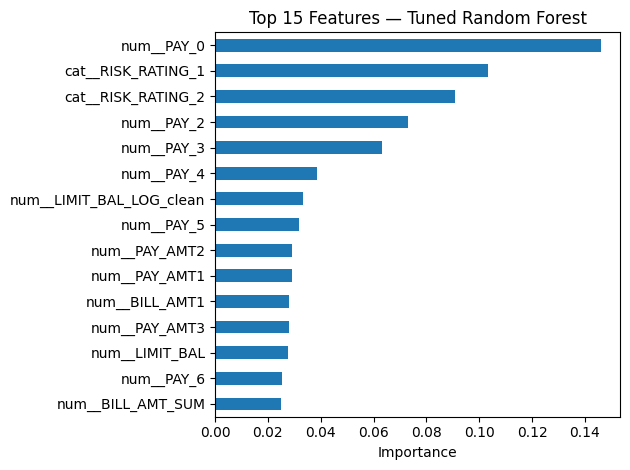

In [21]:
pre_fit = tuned_model.named_steps["preprocessor"]
rf_fit = tuned_model.named_steps["model"]

feature_names = pre_fit.get_feature_names_out()
importances = pd.Series(
    rf_fit.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

display(importances.head(15).to_frame("Importance"))

importances.head(15).sort_values().plot(
    kind="barh",
    title="Top 15 Features — Tuned Random Forest"
)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation

Payment-status variables, `RISK_RATING`, credit-limit variables, payment amounts and `BILL_AMT_SUM` are among the most important predictors. Because `RISK_RATING` is a deterministic grouping of `PAY_0`, their high importance should not be interpreted as two independent signals. `risk_leak` is absent because it was excluded before modelling.

## 14. SHAP interpretation

SHAP is used to measure the average contribution of each transformed feature to the tuned Random Forest predictions.

`risk_leak` does not appear here because it was deliberately removed before legitimate model training.

,Mean absolute SHAP value
num__PAY_0,0.044687
cat__RISK_RATING_1,0.034410
cat__RISK_RATING_2,0.026186
num__PAY_2,0.025806
num__PAY_3,0.022783
num__LIMIT_BAL_LOG_clean,0.016596
num__LIMIT_BAL,0.014481
num__PAY_4,0.013339
num__PAY_AMT2,0.013301
num__PAY_AMT3,0.013148


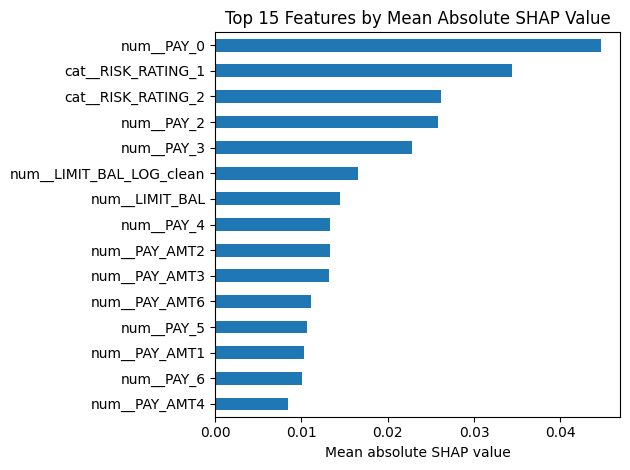

In [22]:
X_test_transformed = pre_fit.transform(X_test)

sample = X_test_transformed[:300]
sample_dense = sample.toarray() if hasattr(sample, "toarray") else sample

explainer = shap.TreeExplainer(rf_fit)
shap_values = explainer.shap_values(sample_dense)

if isinstance(shap_values, list):
    shap_array = np.asarray(shap_values[1])
else:
    shap_array = np.asarray(shap_values)

if shap_array.ndim == 3:
    shap_array = shap_array[:, :, 1]

mean_abs_shap = np.abs(shap_array).mean(axis=0)

shap_importance = pd.Series(
    mean_abs_shap,
    index=feature_names
).sort_values(ascending=False)

display(shap_importance.head(15).to_frame("Mean absolute SHAP value"))

shap_importance.head(15).sort_values().plot(
    kind="barh",
    title="Top 15 Features by Mean Absolute SHAP Value"
)
plt.xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

### SHAP interpretation

The SHAP ranking broadly agrees with impurity-based feature importance. Payment status, risk rating, credit exposure and payment variables are influential. `RISK_RATING` and `PAY_0` are related by construction, so their contributions are not independent. SHAP explains model behaviour but does not establish causality.

## 15. Limitations and future work

### Main limitations

1. The source data cover **April-September 2005**, so current customer behaviour and lending conditions may differ.
2. Demographic variables such as sex, education, age and marriage can produce unequal error rates across groups.
3. **291 rows** contain a mismatch between `BILL_AMT_SUM` and the row-wise sum of `BILL_AMT1` to `BILL_AMT6`; this engineered field therefore has a data-quality limitation.
4. `RISK_RATING` is a deterministic grouping of `PAY_0`, so the two variables should not be treated as independent evidence in interpretation.
5. Median/mode imputation is transparent but may suppress relationships that more advanced imputation methods could retain.
6. Accuracy, F1 and AUC do not directly represent the financial cost of false negatives and false positives.
7. Performance has not yet been externally validated on another customer population.

### Recommended future work

- Run a formal fairness audit across demographic groups.
- Optimise the classification threshold using an explicit financial loss matrix.
- Compare stronger tabular models such as Gradient Boosting or XGBoost.
- Add probability calibration, temporal validation and external validation.
- Monitor model drift before any real-world deployment.

## 16. Final conclusion

This Python workflow demonstrates a complete, reproducible credit-card-default classification pipeline:

**Raw dataset -> EDA -> data-quality checks -> leakage detection -> preprocessing -> training-only cross-validation -> five baseline models -> evaluation -> leakage-safe tuning -> feature importance -> SHAP**

Training-only cross-validation selects **Random Forest** for tuning. The corrected `RandomizedSearchCV` places the full preprocessing pipeline inside every validation fold, preventing validation data from influencing imputation, scaling or encoding. The tuned Random Forest sacrifices some accuracy and precision but improves recall and F1 compared with the baseline model.

The model should therefore be treated as a **decision-support tool**, not an automatic lending decision system. Fairness testing, threshold optimisation, calibration, external validation and ongoing monitoring would be required before deployment.

## 17. Assessment task completion checklist

| Assessment task | Evidence in this notebook | Status |
|---|---|---|
| **Task 1 - Exploratory Data Analysis** | Target imbalance, descriptive statistics, histograms, box plot, categorical distributions, correlations, leakage inspection and `BILL_AMT_SUM` consistency check | **Complete** |
| **Task 2 - Data Preparation** | Missing-value audit, median/mode imputation, missing indicators, one-hot encoding, scaling, reconstructed `LIMIT_BAL_LOG`, leakage removal and explicit before/after example | **Complete** |
| **Task 3 - Model Training** | 80:20 stratified split, five classifiers, algorithm justification, recorded initial hyperparameters and training-only 3-fold CV model selection | **Complete** |
| **Task 4 - Model Evaluation and Visualisation** | Accuracy, precision, recall, F1, ROC-AUC, test-set comparison, five confusion matrices, ROC curves, leakage-safe `RandomizedSearchCV`, before/after tuning comparison, feature importance and SHAP | **Complete** |
| **Task 5 - Conclusion and Future Work** | Findings, data-quality limitations, demographic/fairness concerns and concrete future improvements | **Complete** |

**All five assessment tasks are explicitly represented in the executable Python workflow.**